<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 124 · Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Loan Default Risk &#183; Take It Further</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Five extensions of the credit model: a cost-based threshold, mitigating the fairness gap with per-group cutoffs, hunting proxy features, checking calibration across groups, and generating an applicant's SHAP reason codes, each with a picture and a plain-English explanation.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Loan Default Risk: Take It Further
Five extensions of the Chapter 124 model, each with a picture and a plain explanation: set a **cost-based threshold**, **mitigate** the fairness gap with per-group cutoffs, hunt for **proxy** features that leak the protected attribute, check **calibration across groups**, and generate an applicant's **reason codes** with SHAP. We start by rebuilding the cleaned data and the gradient-boosting model.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, recall_score, precision_score
import warnings; warnings.filterwarnings('ignore'); import shap

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">RECAP &#183; REBUILD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Clean data, model, scores</div>
<div style="color:#4a5578;margin-top:6px">Everything from Chapter 124 in a few cells.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/loan_applications.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'loan_applications.csv')
df = df.drop_duplicates('application_id')
df['annual_income'] = pd.to_numeric(df.annual_income.str.replace(r'[$,]','',regex=True).replace('n/a',np.nan), errors='coerce')
def pe(s):
    s=str(s).strip()
    return np.nan if s in ('','nan') else (10.0 if '10+' in s else (0.0 if '<' in s else float(s.split()[0])))
df['employment_length'] = df.employment_length.map(pe)
df['home_ownership'] = df.home_ownership.str.strip().str.upper(); df['loan_purpose'] = df.loan_purpose.str.strip().str.lower().str.replace(' ','_')
df = df[df.age>=18].copy(); df.loc[df.debt_to_income<0,'debt_to_income']=np.nan
df['loan_to_income'] = df.loan_amount/df.annual_income.replace(0,np.nan)
numeric=['annual_income','credit_score','employment_length','debt_to_income','revolving_util','num_credit_lines','loan_amount','age','loan_to_income']; categorical=['home_ownership','loan_purpose']
X=df[numeric+categorical]; y=df['defaulted']; group=df['group']
X_train,X_test,y_train,y_test,g_train,g_test = train_test_split(X,y,group,test_size=0.25,random_state=0,stratify=y)
pre=ColumnTransformer([('num',Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())]),numeric),('cat',Pipeline([('i',SimpleImputer(strategy='most_frequent')),('o',OneHotEncoder(handle_unknown='ignore'))]),categorical)]).fit(X_train)
names=numeric+list(pre.named_transformers_['cat'].named_steps['o'].get_feature_names_out(categorical))
Xtr_t,Xte_t=pre.transform(X_train),pre.transform(X_test)
gbm=GradientBoostingClassifier(random_state=0).fit(Xtr_t,y_train); prob=gbm.predict_proba(Xte_t)[:,1]
print('recap: GBM test ROC-AUC = %.3f' % roc_auc_score(y_test, prob))

recap: GBM test ROC-AUC = 0.740


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 1 &#183; A COST-BASED THRESHOLD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Deny too much and you lose good business</div>
<div style="color:#4a5578;margin-top:6px">Balance a default against a lost loan.</div>
</div>

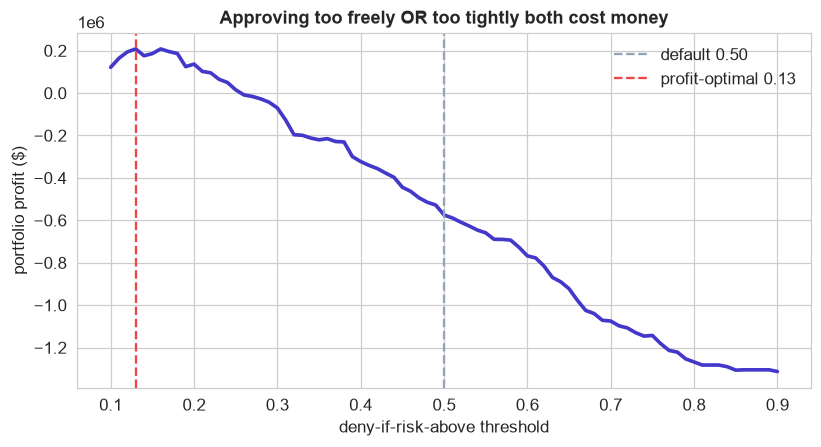

profit-optimal threshold 0.13


In [4]:
LOSS_DEFAULT = 8000     # money lost when a funded loan defaults
PROFIT_GOOD = 1500      # profit from a good loan that repays
yv=y_test.values; ths=np.linspace(0.1,0.9,81); profit=[]
for t in ths:
    approve = prob < t
    profit.append((approve & (yv==0)).sum()*PROFIT_GOOD - (approve & (yv==1)).sum()*LOSS_DEFAULT)
best_t=ths[int(np.argmax(profit))]
fig,ax=plt.subplots(figsize=(7.6,4.2)); ax.plot(ths,profit,color=EM,lw=2.4); ax.axvline(0.5,color=GREY,ls='--',label='default 0.50'); ax.axvline(best_t,color=RED,ls='--',label=f'profit-optimal {best_t:.2f}')
ax.set(xlabel='deny-if-risk-above threshold',ylabel='portfolio profit ($)',title='Approving too freely OR too tightly both cost money'); ax.legend(); plt.tight_layout(); plt.show()
print('profit-optimal threshold %.2f' % best_t)

**The threshold is a portfolio decision.** Deny at too low a risk and you turn away profitable, repaying customers; approve too freely and defaults eat the returns. Because a default (about $8,000 lost) costs far more than a good loan earns (about $1,500), the profit curve peaks **well below 0.5**, around a 0.13 risk cutoff: the lender should fund only fairly low-risk applicants. That break-even point, not the arbitrary 0.5, is the true risk appetite, the same cost-tuning idea as the fraud and maintenance chapters, now in dollars of portfolio profit.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 2 &#183; MITIGATE THE FAIRNESS GAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Per-group thresholds</div>
<div style="color:#4a5578;margin-top:6px">Equalize the error that matters, at a price.</div>
</div>

Group A threshold 0.50 -> good wrongly denied 0.053
Group B threshold 0.50 -> good wrongly denied 0.070 (the gap)
Group B threshold 0.56 -> good wrongly denied 0.051 (gap closed)


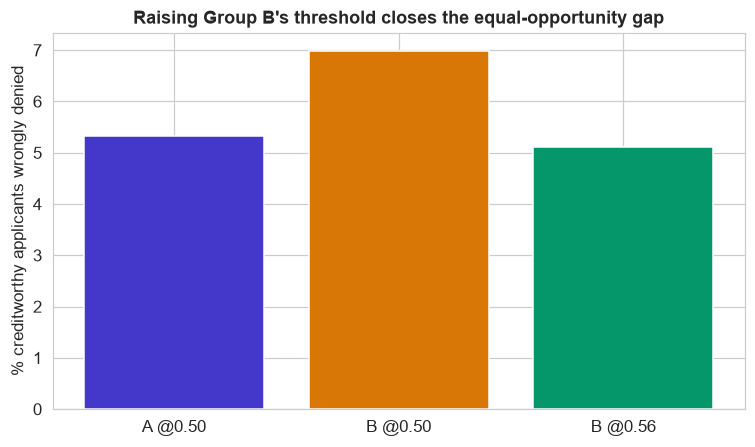

trade-off: Group B defaults caught falls from 37% to 33% (we approve more B, including some who default)


In [5]:
def rates(mask, thresh):
    sub_prob=prob[mask]; sub_y=yv[mask]; deny=sub_prob>=thresh; good=sub_y==0
    return deny[good].mean()   # good applicants wrongly denied (what equal opportunity targets)
A=g_test.values=='A'; B=g_test.values=='B'
target_gap = rates(A,0.5)   # match Group B's wrongful-denial rate to Group A's
tB=0.5
for t in np.linspace(0.5,0.85,71):
    if rates(B,t) <= target_gap: tB=t; break
print('Group A threshold 0.50 -> good wrongly denied %.3f' % rates(A,0.5))
print('Group B threshold 0.50 -> good wrongly denied %.3f (the gap)' % rates(B,0.5))
print('Group B threshold %.2f -> good wrongly denied %.3f (gap closed)' % (tB, rates(B,tB)))
denyB_before=(prob[B]>=0.5); denyB_after=(prob[B]>=tB)
fig,ax=plt.subplots(figsize=(7,4.2))
ax.bar(['A @0.50','B @0.50','B @%.2f'%tB],[rates(A,0.5)*100, rates(B,0.5)*100, rates(B,tB)*100],color=[EM,AMBER,GREEN])
ax.set(ylabel='% creditworthy applicants wrongly denied',title='Raising Group B\'s threshold closes the equal-opportunity gap'); plt.tight_layout(); plt.show()
print('trade-off: Group B defaults caught falls from %.0f%% to %.0f%% (we approve more B, including some who default)' % ((prob[B & (yv==1)]>=0.5).mean()*100,(prob[B & (yv==1)]>=tB).mean()*100))

**Fairness has a lever, and a cost.** One standard mitigation is a **group-specific threshold**: raise Group B's deny-cutoff so its creditworthy applicants are wrongly denied at the same rate as Group A's, closing the equal-opportunity gap. It works, but nothing is free, approving more Group B applicants also lets a few more true defaults through. There is a genuine trade-off between group fairness and accuracy, and, moreover, using the protected attribute to set thresholds is itself legally fraught. The real lesson is that fairness is a **deliberate choice with consequences**, to be made openly with legal and ethical input, not a checkbox.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 3 &#183; HUNT THE PROXIES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How does disparity leak in?</div>
<div style="color:#4a5578;margin-top:6px">Try to predict the protected group from the features.</div>
</div>

predicting the protected group from the OTHER features: ROC-AUC = 0.72
(0.5 would mean the features carry no information about the group)


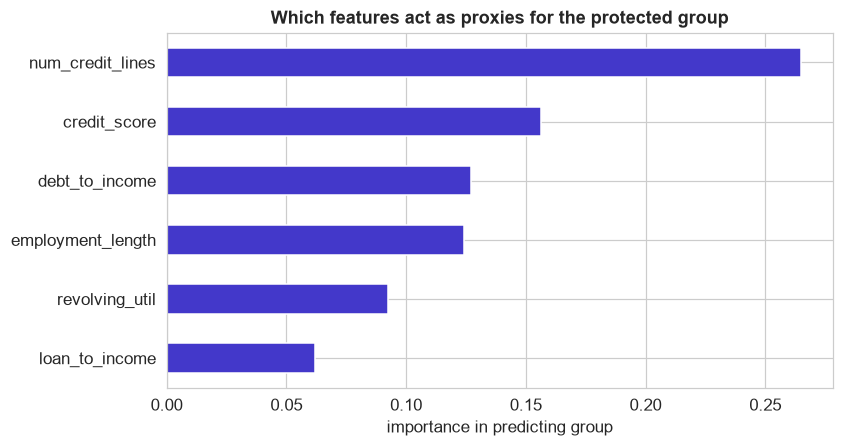

In [6]:
gy = (g_test.values=='B').astype(int); gy_tr=(g_train.values=='B').astype(int)
proxy = GradientBoostingClassifier(random_state=0).fit(Xtr_t, gy_tr)
proxy_auc = roc_auc_score(gy, proxy.predict_proba(Xte_t)[:,1])
imp = pd.Series(proxy.feature_importances_, index=names).sort_values().tail(6)
print('predicting the protected group from the OTHER features: ROC-AUC = %.2f' % proxy_auc)
print('(0.5 would mean the features carry no information about the group)')
fig,ax=plt.subplots(figsize=(7.8,4.2)); imp.plot.barh(ax=ax,color=EM); ax.set(title='Which features act as proxies for the protected group',xlabel='importance in predicting group'); plt.tight_layout(); plt.show()

**This is why blindness fails.** If the protected attribute were truly independent of the features, a model could not recover it, and dropping it would guarantee fairness. But here a model predicts the group from the other features with **AUC well above 0.5**: income, credit score, and credit history all carry information about the group. Those are the **proxies** through which disparity enters, and they are also legitimate risk factors, which is exactly what makes fair lending hard. You cannot fix what you refuse to measure.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 4 &#183; CALIBRATED FOR BOTH GROUPS?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A subtler fairness question</div>
<div style="color:#4a5578;margin-top:6px">Does a '30%' mean 30% for everyone?</div>
</div>

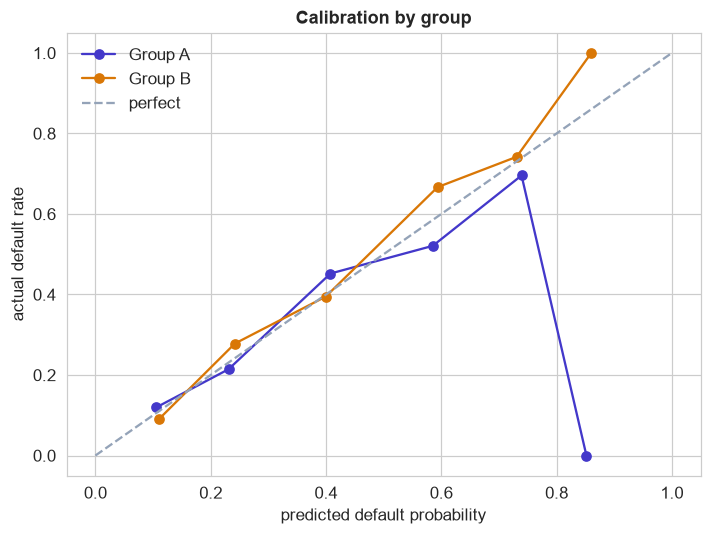

both curves track the diagonal -> a predicted risk means about the same thing for either group


In [7]:
fig,ax=plt.subplots(figsize=(6.6,5))
for gg,c in [('A',EM),('B',AMBER)]:
    m=g_test.values==gg; frac,mean=calibration_curve(y_test.values[m],prob[m],n_bins=6)
    ax.plot(mean,frac,'o-',color=c,label=f'Group {gg}')
ax.plot([0,1],[0,1],'--',color=GREY,label='perfect'); ax.set(xlabel='predicted default probability',ylabel='actual default rate',title='Calibration by group'); ax.legend()
plt.tight_layout(); plt.show()
print('both curves track the diagonal -> a predicted risk means about the same thing for either group')

**Calibration is a different fairness lens.** Even if approval rates differ, the scores can still be **equally honest** for both groups: when the model says 30% for a Group A applicant and 30% for a Group B applicant, do both default about 30% of the time? The by-group reliability curves both hug the diagonal, so the *risk estimates* are unbiased, the disparity is in the base rates and the shared threshold, not in miscalibrated scores. Different fairness definitions (calibration, equal opportunity, demographic parity) can even conflict; picking which to enforce is a value judgement.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 5 &#183; REASON CODES FOR AN APPLICANT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The adverse-action notice</div>
<div style="color:#4a5578;margin-top:6px">SHAP turns a denial into an explanation.</div>
</div>

In [8]:
explainer=shap.TreeExplainer(gbm); sv=explainer(Xte_t); sv.feature_names=names
i=int(np.argmax(prob))   # the highest-risk applicant
contrib=pd.Series(sv.values[i],index=names).sort_values(ascending=False)
print('applicant predicted default probability = %.0f%%' % (prob[i]*100))
print('\ntop reasons this application was flagged high-risk (adverse-action reason codes):')
for f,v in contrib.head(4).items(): print(f'  - {f:22s} (impact +{v:.2f})')
print('\ntop factors in the applicant\'s FAVOR:')
for f,v in contrib.tail(2).items(): print(f'  - {f:22s} (impact {v:.2f})')

applicant predicted default probability = 89%

top reasons this application was flagged high-risk (adverse-action reason codes):
  - debt_to_income         (impact +1.54)
  - revolving_util         (impact +1.47)
  - credit_score           (impact +0.48)
  - employment_length      (impact +0.22)

top factors in the applicant's FAVOR:
  - loan_to_income         (impact -0.16)
  - annual_income          (impact -0.30)


**A denial you can put in writing.** SHAP decomposes one applicant's risk score into per-feature contributions, and the largest positive ones become the **reason codes** a lender is legally required to send with a denial: 'your application was declined primarily because of your debt-to-income ratio, credit score, and card utilization.' The same decomposition also surfaces the factors in the applicant's favor. This turns an opaque model output into a specific, actionable, and compliant explanation, the practical reason SHAP is indispensable in regulated modeling.

## Take-it-further summary, in plain terms

- **The threshold is a portfolio choice**: too strict loses good loans, too loose invites defaults; tune it to the money.
- **Fairness can be mitigated but not for free**: per-group thresholds close the gap at some cost in accuracy, and are a deliberate, governed decision.
- **Proxies leak the protected attribute**: the other features predict the group, which is exactly why dropping the attribute does not ensure fairness.
- **The scores are calibrated for both groups**: risk estimates are equally honest, so the disparity lives in base rates and thresholds, not biased scores.
- **SHAP produces reason codes**: the legally-required explanation behind every denial, straight from the model.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>